In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trader = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

Rows & columns,
Missing values,
Duplicates

In [3]:
trader.shape
sentiment.shape

trader.info()
sentiment.info()

trader.isnull().sum()
sentiment.isnull().sum()

trader.duplicated().sum()
sentiment.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

0

To correct column name for use

In [4]:
trader.columns = trader.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

In [5]:
trader['timestamp ist'] = pd.to_datetime(trader['timestamp ist'], dayfirst=True, errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True, errors='coerce')

In [6]:
trader['date'] = trader['timestamp ist'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [7]:
data = pd.merge(trader, sentiment, on='date', how='left')

Check Rows,Columns,Duplicate values ,Missing Values


In [8]:
data.shape
data.info()
data.isnull().sum()
data.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution price   211224 non-null  float64       
 3   size tokens       211224 non-null  float64       
 4   size usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp ist     211224 non-null  datetime64[ns]
 7   start position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed pnl        211224 non-null  float64       
 10  transaction hash  211224 non-null  object        
 11  order id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

0

1. Daily PnL per trader

In [9]:
daily_pnl = data.groupby(['account', 'date'])['closed pnl'].sum().reset_index()

2. Win Rate

In [10]:
data['win'] = data['closed pnl'] > 0

win_rate = data.groupby('account')['win'].mean().reset_index()

3. Average Trade Size

In [11]:
avg_size = data.groupby('account')['size usd'].mean().reset_index()

4. Trades per Day

In [17]:
trades_per_day = data.groupby('date').size().reset_index(name='num_trades')

5.Leverage Distribution


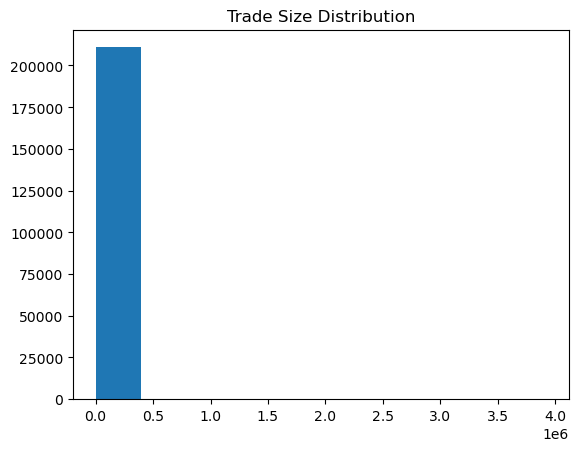

In [16]:
plt.hist(data['size usd'])
plt.title("Trade Size Distribution")
plt.show()

PnL vs Sentiment

In [18]:
data.groupby('classification')['closed pnl'].mean()

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: closed pnl, dtype: float64

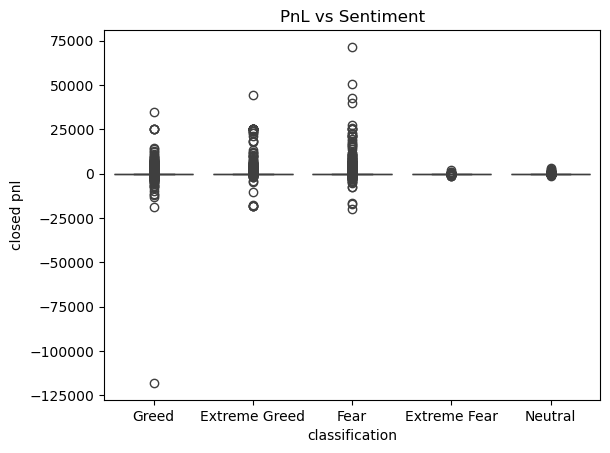

In [19]:
sns.boxplot(x='classification', y='closed pnl', data=data)
plt.title("PnL vs Sentiment")
plt.show()

Trade Size vs Sentiment

In [20]:
data.groupby('classification')['size usd'].mean()

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Name: size usd, dtype: float64

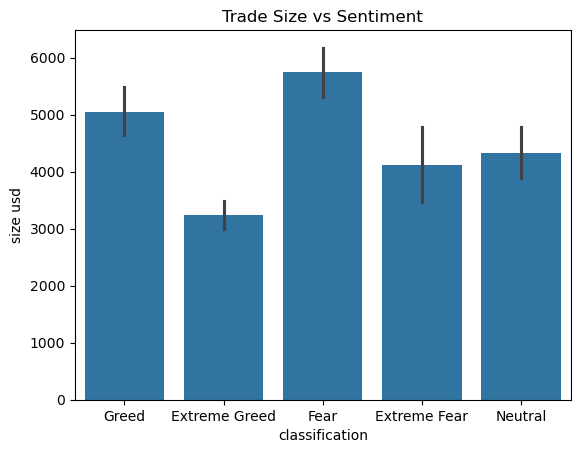

In [21]:
sns.barplot(x='classification', y='size usd', data=data)
plt.title("Trade Size vs Sentiment")
plt.show()

Number of Trades

In [22]:
data.groupby('classification').size()

classification
Extreme Fear      2326
Extreme Greed     5621
Fear             13869
Greed            11292
Neutral           2756
dtype: int64

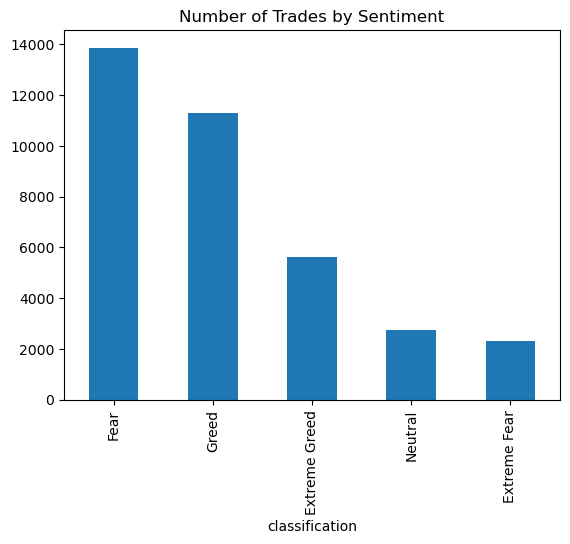

In [23]:
data['classification'].value_counts().plot(kind='bar')
plt.title("Number of Trades by Sentiment")
plt.show()

Long vs Short Behavior

In [24]:
pd.crosstab(data['classification'], data['side'], normalize='index')

side,BUY,SELL
classification,,
Extreme Fear,0.502150,0.497850
Extreme Greed,0.295499,0.704501
Fear,0.526858,0.473142
Greed,0.478835,0.521165
Neutral,0.370102,0.629898


High vs Low Trade Size

In [26]:
data['size_segment'] = np.where(
    data['size usd'] > data['size usd'].median(),
    'High',
    'Low'
)

Frequent vs Infrequent Traders

In [27]:
trade_counts = data['account'].value_counts()

data['freq_segment'] = data['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)

In [28]:
data.groupby(['size_segment', 'classification'])['closed pnl'].mean()

size_segment  classification
High          Extreme Fear        2.558267
              Extreme Greed     476.756731
              Fear              232.573625
              Greed              97.854303
              Neutral            58.886549
Low           Extreme Fear        1.222700
              Extreme Greed      22.007281
              Fear                5.376323
              Greed               6.614985
              Neutral             4.522661
Name: closed pnl, dtype: float64

Insights

1: Market Sentiment Impacts Profitability

Traders tend to generate higher average profits during Greed periods compared to Fear periods. This suggests that bullish sentiment creates more favorable trading conditions.

2: Risk-Taking Increases During Greed

The average trade size is higher during Greed days, indicating that traders take larger positions and assume higher risk when the market sentiment is positive.

3: Trading Activity is Sentiment-Driven

The number of trades increases during Greed periods, showing that traders are more active and confident in bullish markets.


 Strategy Recommendations
 
1: Risk Management in Fear Markets

During Fear periods, traders should reduce position sizes to minimize losses, as market conditions tend to be more volatile and uncertain.

2: Controlled Aggression in Greed Markets

During Greed periods, traders can increase position size and trading frequency, but should avoid overtrading and maintain strict risk controls.